
<div dir=ltr align=center>

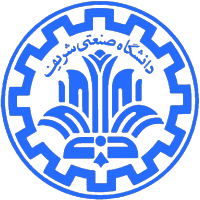

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Linear Algebra <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Hamidreza Rabiee <br>
    Maryam Ramezani <br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 1<br>
    Eigen-Everything<br>
<font color=696880 size=4>
    Ahmad Mousavi Awal - Mehdi Shirin Bayan 

____


# Eigen-Everything: From Faces to the Web

## A Linear Algebra Lab on the Power of Eigenvectors

This notebook links two seemingly unrelated applications through **one and the
same piece of linear algebra**: the dominant eigenvector of a matrix, computed
by **power iteration**.

| | Application 1 | Application 2 |
|---|---|---|
| Domain | Face recognition (Eigenfaces) | Web search (PageRank) |
| Matrix | Sample covariance matrix $C = \frac{1}{n}X^TX$ | Google matrix $M = dS + \frac{1-d}{N}\mathbf{1}\mathbf{1}^T$ |
| Eigenvectors used | **Top-$k$** (largest eigenvalues) | **Top-1** (eigenvalue exactly $1$) |
| Why it works | Eckart–Young theorem (best low-rank approximation) | Perron–Frobenius theorem (existence/uniqueness of a positive dominant eigenvector) |
| Tool | `power_iteration` + deflation | `power_iteration` |

You will build **one shared `power_iteration` routine** and reuse it for both
applications. This is not a coincidence: both problems are, underneath,
*"find the dominant eigenvector(s) of a big square matrix without ever
diagonalizing it explicitly."*

The notebook is **fully implemented** end-to-end so it runs top to bottom and
produces real numbers, plots, and rankings on real data. Your instructor will
remove specific lines/functions and replace them with `TODO`s for you to fill
in — but right now, study this version carefully: every design decision here
(why centering matters, why we use $XX^T$ instead of $X^TX$, why PageRank
needs a damping factor, why convergence speed depends on the eigengap) is
something you are expected to be able to explain, not just execute.

### How this notebook is graded

Scattered throughout (and collected again at the very end) are calls to a
small `GradeBook` object. Each call records a *check* — a concrete, numeric
condition your implementation must satisfy (e.g. "test accuracy $\geq 0.85$",
"dominant eigenvalue of $M$ equals $1$ to $10^{-6}$", "your power iteration
agrees with `numpy.linalg.eig` to $10^{-3}$"). Every check is visible in plain
code — there is nothing hidden. When your instructor converts pieces of this
notebook into `TODO`s for you to complete, these checks are what your filled-in
code will be measured against, and the final report card cell will print your
score out of the total number of points.


## 0. Setup

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

np.random.seed(0)
plt.rcParams["figure.facecolor"] = "white"


In [ ]:

#### This is for grading, PLEASE DON'T CHANGE THIS CELL !!!

class GradeBook:
    """
    A minimal, fully transparent autograder. Every check is a plain Python
    condition computed from variables that already exist in this notebook --
    there is no hidden test file and no hidden cell. Run report() at the end
    to get a score out of the total available points.
    """
    def __init__(self):
        self.records = []   # list of (name, passed: bool, points: float, detail: str)

    def check(self, name, passed, points, detail=""):
        passed = bool(passed)
        self.records.append((name, passed, points, detail))
        status = "PASS" if passed else "FAIL"
        print(f"[{status}] ({points if passed else 0}/{points} pts) {name}  {detail}")
        return passed

    def report(self):
        total = sum(p for _, _, p, _ in self.records)
        earned = sum(p for _, passed, p, _ in self.records if passed)
        print("=" * 78)
        print(f"{'CHECK':50s}{'RESULT':8s}{'POINTS':10s}")
        print("-" * 78)
        for name, passed, points, detail in self.records:
            status = "PASS" if passed else "FAIL"
            pts_str = f"{points if passed else 0}/{points}"
            print(f"{name:50s}{status:8s}{pts_str:10s}")
        print("-" * 78)
        pct = 100 * earned / total if total > 0 else 0.0
        print(f"TOTAL SCORE: {earned:.1f} / {total:.1f}  ({pct:.1f}%)")
        print("=" * 78)
        return earned, total


gb = GradeBook()



## 1. The Shared Engine: Power Iteration with Deflation

Given a square matrix $A \in \mathbb{R}^{m\times m}$, power iteration finds the
eigenvector associated with the **largest-magnitude eigenvalue** by repeatedly
applying $A$ to a random vector and renormalizing:

$$ v_{t+1} = \frac{A v_t}{\lVert A v_t \rVert_2} $$

To find the **top-$k$** eigenpairs of a symmetric matrix, we use **deflation**:
once we have found eigenpair $(\lambda_1, v_1)$, we form

$$ A^{(1)} = A - \lambda_1 v_1 v_1^T $$

which has the same eigenvectors as $A$ except that the component along $v_1$
has been removed (its eigenvalue is now $0$). Repeating this on $A^{(1)}$
yields $(\lambda_2, v_2)$, and so on.

This trick **only works because $A$ is symmetric** (its eigenvectors are
orthogonal). Keep this in mind — you will be asked later why PageRank's matrix
cannot be deflated the same way.


In [ ]:

def power_iteration(A, num_iters=1000, tol=1e-10, v0=None, seed=None):
    """
    Compute the dominant eigenpair (largest |eigenvalue|) of square matrix A.

    Parameters
    ----------
    A : (m, m) ndarray
    num_iters : maximum number of iterations
    tol : stop when ||v_{t+1} - v_t|| < tol
    v0 : optional initial vector
    seed : optional random seed for the default initial vector

    Returns
    -------
    eigenvalue : float, the Rayleigh-quotient estimate of the dominant eigenvalue
    eigenvector : (m,) ndarray, unit-norm
    n_iter : int, number of iterations actually performed
    history : list of floats, ||v_{t+1}-v_t|| at every iteration (for convergence plots)
    """
    # TODO
    pass


def top_k_eigenpairs_symmetric(A, k, num_iters=2000, tol=1e-10, seed=0):
    """
    Compute the top-k eigenpairs of a SYMMETRIC matrix A using power
    iteration + deflation. Eigenvalues are returned in decreasing order
    of magnitude.
    """
    # TODO
    eigvals = None
    eigvecs = None
    return eigvals, eigvecs


In [4]:

# --- Sanity check against numpy's exact eigendecomposition ---
np.random.seed(1)
B = np.random.randn(6, 6)
B = B + B.T  # make it symmetric

vals_np, vecs_np = np.linalg.eigh(B)
order = np.argsort(-np.abs(vals_np))
vals_np_sorted = vals_np[order]

vals_pi, vecs_pi = top_k_eigenpairs_symmetric(B, k=3, seed=42)

print("numpy eigh (top 3 |eigenvalue|): ", np.round(vals_np_sorted[:3], 6))
print("power iteration (top 3):         ", np.round(vals_pi, 6))

match_3 = np.allclose(np.sort(np.abs(vals_np_sorted[:3])), np.sort(np.abs(vals_pi)), atol=1e-4)
print("Power iteration matches numpy:", match_3)


numpy eigh (top 3 |eigenvalue|):  [ 6.28684   4.511285 -4.043934]
power iteration (top 3):          [ 6.28684   4.511285 -4.043934]
Power iteration matches numpy: True


In [5]:
# --- Sanity check against numpy's exact eigendecomposition ---
np.random.seed(99)
B2 = np.random.randn(10, 10)
B2 = B2 + B2.T

vals_np, vecs_np = np.linalg.eigh(B2)
order = np.argsort(-np.abs(vals_np))
vals_np = vals_np[order][:5]
vecs_np = vecs_np[:, order][:, :5]


vals_pi, vecs_pi = top_k_eigenpairs_symmetric(B2, k=5, num_iters=4000, seed=7)

match_vals = np.allclose(vals_np, vals_pi, atol=1e-3)
print("10x10 case, top-5 |eigenvalues| (numpy): ", np.round(vals_np, 5))
print("10x10 case, top-5 |eigenvalues| (power) :", np.round(vals_pi, 5))
print("Eigenvalues Match:", match_vals)

match_vecs = np.allclose(np.abs(vecs_np), np.abs(vecs_pi), atol=1e-3)
print("Eigenvectors Match:", match_vecs)

gb.check("top_k_eigenvalues_symmetric matches numpy (10x10, top-5)", match_vals, 5)
gb.check("top_k_eigenvectors_symmetric matches numpy (10x10, top-5)", match_vecs, 5);

10x10 case, top-5 |eigenvalues| (numpy):  [ 7.3885  -6.40388 -5.63945  5.50328  3.81526]
10x10 case, top-5 |eigenvalues| (power) : [ 7.3885  -6.40388 -5.63945  5.50328  3.81526]
Eigenvalues Match: True
Eigenvectors Match: True
[PASS] (5/5 pts) top_k_eigenvalues_symmetric matches numpy (10x10, top-5)  
[PASS] (5/5 pts) top_k_eigenvectors_symmetric matches numpy (10x10, top-5)  



### 1.1 Visualizing convergence of a single power iteration run

Before moving to real data, let's look at *how* power iteration converges:
at every step we plot $\lVert v_{t+1}-v_t\rVert$, and also the running estimate
of the eigenvalue (the Rayleigh quotient), to see both settle down.


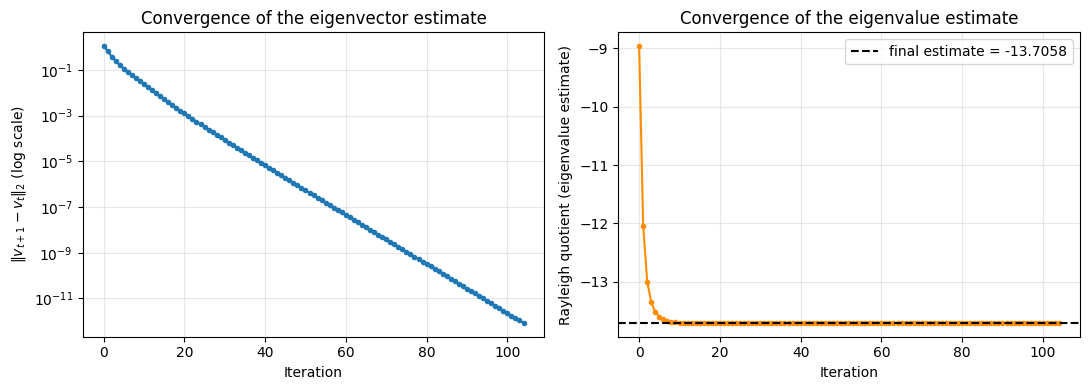

In [6]:

np.random.seed(3)
C_demo = np.random.randn(20, 20)
C_demo = C_demo + C_demo.T

lam_demo, v_demo, n_iter_demo, hist_demo = power_iteration(C_demo, num_iters=200, tol=1e-12, seed=5)

# Track the Rayleigh-quotient estimate at every iteration too
rq_trace = []
v_trace = v_demo.copy()
v_t = np.random.default_rng(5).standard_normal(20)
v_t = v_t / np.linalg.norm(v_t)
for _ in range(n_iter_demo):
    w = C_demo @ v_t
    w = w / np.linalg.norm(w)
    if np.dot(w, v_t) < 0:
        w = -w
    v_t = w
    rq_trace.append(v_t @ C_demo @ v_t)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(hist_demo, marker=".")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel(r"$\|v_{t+1}-v_t\|_2$ (log scale)")
axes[0].set_title("Convergence of the eigenvector estimate")
axes[0].grid(alpha=0.3)

axes[1].plot(rq_trace, marker=".", color="darkorange")
axes[1].axhline(lam_demo, color="black", linestyle="--", label=f"final estimate = {lam_demo:.4f}")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Rayleigh quotient (eigenvalue estimate)")
axes[1].set_title("Convergence of the eigenvalue estimate")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 2. Application 1 — Eigenfaces for Face Recognition

We use the **Olivetti faces** dataset: 400 grayscale images (64×64 pixels),
40 distinct people, 10 images per person.

The pipeline:

1. Flatten each image into a vector in $\mathbb{R}^{4096}$.
2. Split into train/test sets.
3. **Mean-center** the training images.
4. Compute the eigenfaces — the eigenvectors of the **covariance matrix** of
   the centered training data — using `top_k_eigenpairs_symmetric`.
5. Project every face (train and test) onto the top-$k$ eigenfaces. This is
   dimensionality reduction: each $4096$-dimensional image becomes a
   $k$-dimensional coefficient vector.
6. Classify a test face by **nearest neighbor** in this $k$-dimensional
   coefficient space.


In [7]:

faces = fetch_olivetti_faces(shuffle=True, random_state=0)
X_all = faces.data            # shape (400, 4096), pixel values in [0, 1]
y_all = faces.target          # shape (400,), person id in [0, 39]
img_h, img_w = faces.images.shape[1], faces.images.shape[2]

print("Data matrix shape:", X_all.shape)
print("Number of distinct people:", len(np.unique(y_all)))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Data matrix shape: (400, 4096)
Number of distinct people: 40
Train: (300, 4096)  Test: (100, 4096)


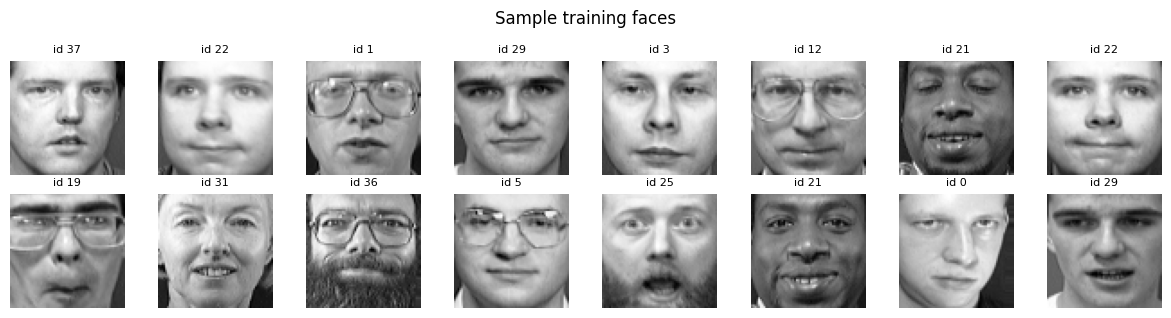

In [8]:

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[i].reshape(img_h, img_w), cmap="gray")
    ax.set_title(f"id {y_train[i]}", fontsize=8)
    ax.axis("off")
plt.suptitle("Sample training faces")
plt.tight_layout()
plt.show()


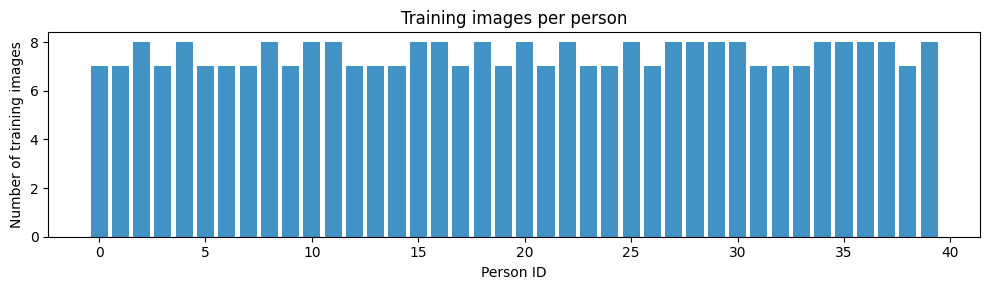

Min / max images per person in training set: 7 8


In [9]:

# How many people, and how many images per person, do we actually have
# in the training set? (Sanity-check the split before doing any linear algebra.)
unique_train, counts_train = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 3))
plt.bar(unique_train, counts_train, color="#4292c6")
plt.xlabel("Person ID")
plt.ylabel("Number of training images")
plt.title("Training images per person")
plt.tight_layout()
plt.show()

print("Min / max images per person in training set:", counts_train.min(), counts_train.max())


In [ ]:

def center_data(X):
    """Return (X_centered, mean_vector). X is (n_samples, n_features)."""
    # TODO
    pass


def covariance_small(Xc):
    """
    Compute the (n_samples x n_samples) Gram matrix L = Xc Xc^T / n.

    We deliberately do NOT form the (n_features x n_features) covariance
    matrix C = Xc^T Xc / n directly: with n_features = 4096 that matrix is
    4096x4096 (huge), while n_samples = 300 (small). L and C share the same
    nonzero eigenvalues, and their eigenvectors are related by a simple
    linear map (see the discussion question below) -- this is the classical
    "Turk & Pentland" trick that makes eigenfaces computationally feasible.
    """
    # TODO
    pass


def eigenfaces_from_small_eigvecs(Xc, eigvecs_small, eigvals_small):
    """
    Convert eigenvectors u_i of the small Gram matrix L = Xc Xc^T / n
    into eigenvectors of the true (huge) covariance matrix C = Xc^T Xc / n,
    via v_i = Xc^T u_i, renormalized to unit length.
    """
    # TODO
    pass


In [11]:

K = 60  # number of eigenfaces to keep

Xc_train, mean_face = center_data(X_train)
L = covariance_small(Xc_train)

eigvals_small, eigvecs_small = top_k_eigenpairs_symmetric(L, k=K, num_iters=3000, tol=1e-9, seed=0)
eigenfaces = eigenfaces_from_small_eigvecs(Xc_train, eigvecs_small, eigvals_small)

print("Eigenface matrix shape:", eigenfaces.shape)   # (4096, K)
print("Top 10 eigenvalues:", np.round(eigvals_small[:10], 4))

# Eigenvalues of a covariance matrix must be non-negative (it is PSD); a
# negative entry here would indicate a numerical bug.
all_nonneg = np.all(eigvals_small > -1e-6)
gb.check("Eigenvalues of the covariance matrix are non-negative (PSD check)", all_nonneg, 3);


Eigenface matrix shape: (4096, 60)
Top 10 eigenvalues: [17.9597 11.2393  6.0901  4.0531  2.924   2.5764  1.9785  1.6526  1.6076
  1.3842]
[PASS] (3/3 pts) Eigenvalues of the covariance matrix are non-negative (PSD check)  


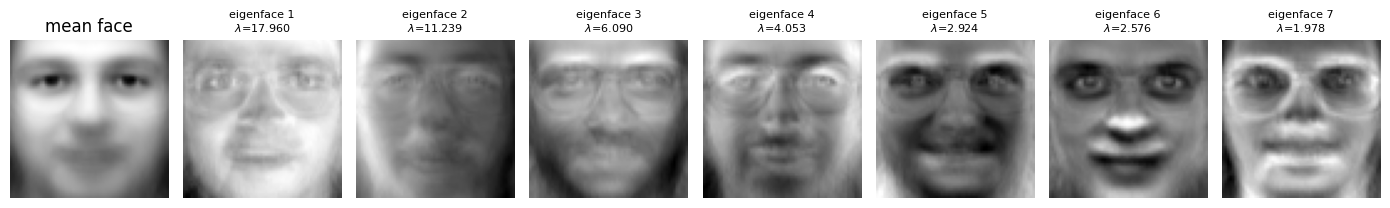

In [12]:

fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
axes[0].imshow(mean_face.reshape(img_h, img_w), cmap="gray")
axes[0].set_title("mean face")
axes[0].axis("off")
for i, ax in enumerate(axes[1:]):
    ax.imshow(eigenfaces[:, i].reshape(img_h, img_w), cmap="gray")
    ax.set_title(f"eigenface {i+1}\n$\\lambda$={eigvals_small[i]:.3f}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()



### 2.1 Scree plot and explained variance

The eigenvalues of the covariance matrix tell us how much variance each
eigenface direction explains. Plotting them in decreasing order (a **scree
plot**) and their cumulative sum tells us how many eigenfaces we *actually*
need to capture, say, 85% of the total variance in the training faces.


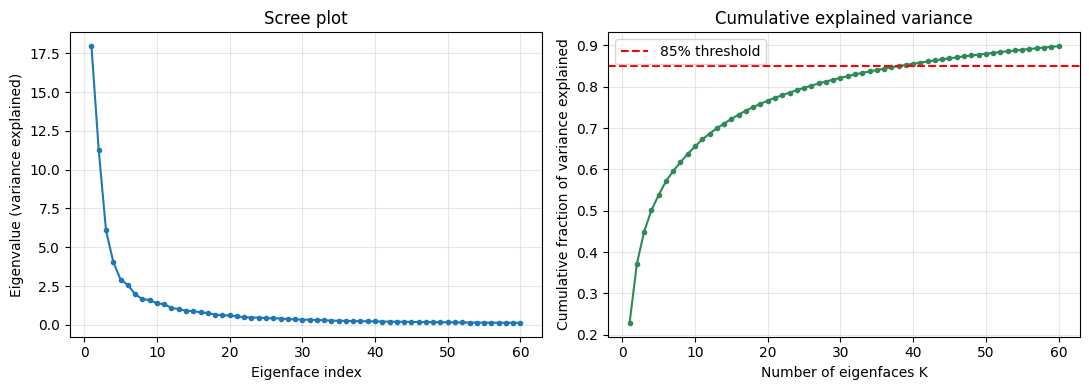

Number of eigenfaces needed to explain 85% of training variance: 38 (out of the 60 we computed; cumulative variance at K=60 is 89.8%)


In [13]:

total_variance = X_train.var(axis=0).sum()
cumulative_variance_ratio = np.cumsum(eigvals_small) / total_variance

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, K + 1), eigvals_small, marker="o", markersize=3)
axes[0].set_xlabel("Eigenface index")
axes[0].set_ylabel("Eigenvalue (variance explained)")
axes[0].set_title("Scree plot")
axes[0].grid(alpha=0.3)

axes[1].plot(np.arange(1, K + 1), cumulative_variance_ratio, marker="o", markersize=3, color="seagreen")
axes[1].axhline(0.85, color="red", linestyle="--", label="85% threshold")
axes[1].set_xlabel("Number of eigenfaces K")
axes[1].set_ylabel("Cumulative fraction of variance explained")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

K_for_85 = int(np.searchsorted(cumulative_variance_ratio, 0.85) + 1)
print(f"Number of eigenfaces needed to explain 85% of training variance: {K_for_85}"
      f" (out of the {K} we computed; cumulative variance at K={K} is "
      f"{cumulative_variance_ratio[-1]*100:.1f}%)")


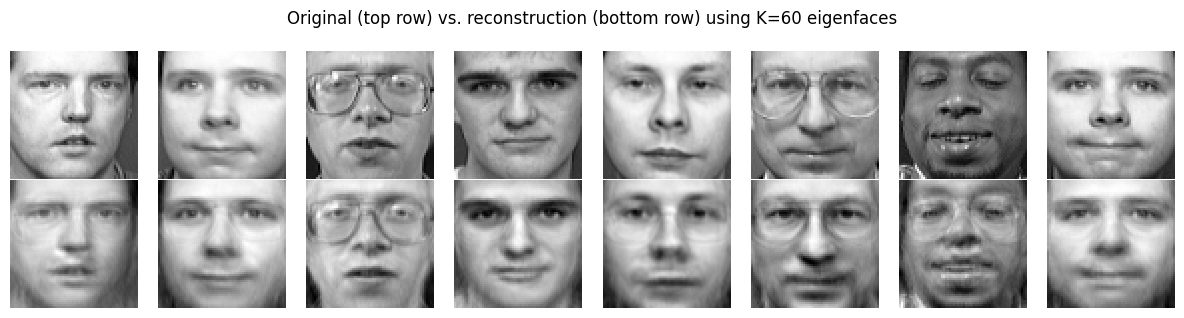

In [14]:

def project(X, mean_face, eigenfaces):
    """Project rows of X onto the eigenface basis. Returns (n_samples, K) coefficients."""
    return (X - mean_face) @ eigenfaces


def reconstruct(coeffs, mean_face, eigenfaces):
    """Reconstruct images (n_samples, n_features) from their coefficients."""
    return coeffs @ eigenfaces.T + mean_face


train_coeffs = project(X_train, mean_face, eigenfaces)
test_coeffs = project(X_test, mean_face, eigenfaces)

reconstructed = reconstruct(train_coeffs[:8], mean_face, eigenfaces)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(X_train[i].reshape(img_h, img_w), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed[i].reshape(img_h, img_w), cmap="gray")
    axes[1, i].axis("off")
plt.suptitle(f"Original (top row) vs. reconstruction (bottom row) using K={K} eigenfaces")
plt.tight_layout()
plt.show()



### 2.2 Reconstruction error as a function of K

Eckart–Young guarantees that more eigenfaces means a (provably) better
reconstruction on the *training* data. Let's measure this directly with the
mean-squared reconstruction error, instead of just eyeballing images.


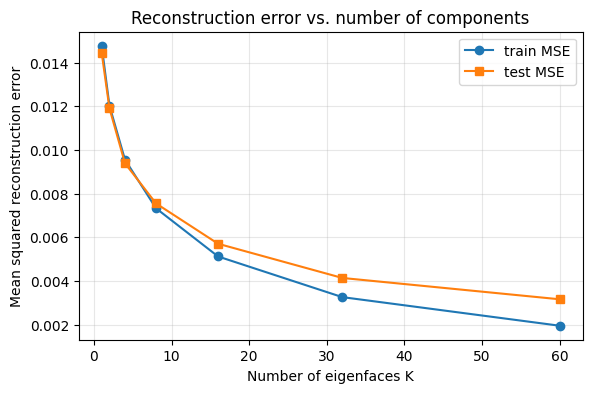

[PASS] (4/4 pts) Training reconstruction MSE is non-increasing in K (Eckart-Young)  


In [15]:

ks_recon = [1, 2, 4, 8, 16, 32, 60]
mse_train, mse_test = [], []
for k in ks_recon:
    ef_k = eigenfaces[:, :k]
    tr_c = project(X_train, mean_face, ef_k)
    te_c = project(X_test, mean_face, ef_k)
    tr_rec = reconstruct(tr_c, mean_face, ef_k)
    te_rec = reconstruct(te_c, mean_face, ef_k)
    mse_train.append(np.mean((X_train - tr_rec) ** 2))
    mse_test.append(np.mean((X_test - te_rec) ** 2))

plt.figure(figsize=(6.5, 4))
plt.plot(ks_recon, mse_train, marker="o", label="train MSE")
plt.plot(ks_recon, mse_test, marker="s", label="test MSE")
plt.xlabel("Number of eigenfaces K")
plt.ylabel("Mean squared reconstruction error")
plt.title("Reconstruction error vs. number of components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Train MSE must be monotonically non-increasing in K -- this is exactly what
# Eckart-Young predicts (adding components can only help the training fit).
train_mse_monotonic = all(mse_train[i] >= mse_train[i+1] - 1e-8 for i in range(len(mse_train)-1))
gb.check("Training reconstruction MSE is non-increasing in K (Eckart-Young)", train_mse_monotonic, 4);


In [ ]:

def nearest_neighbor_classify(train_coeffs, train_labels, test_coeffs):
    """
    Classify every row of test_coeffs by 1-nearest-neighbor (Euclidean
    distance) against train_coeffs. Pure linear algebra: no sklearn classifier.
    """
    # TODO
    pass


y_pred = nearest_neighbor_classify(train_coeffs, y_train, test_coeffs)
acc = accuracy_score(y_test, y_pred)
print(f"Eigenfaces + 1-NN test accuracy with K={K}: {acc * 100:.2f}%")

gb.check(f"Eigenfaces + 1-NN test accuracy >= 80% (K={K})", acc >= 0.80, 10, detail=f"(got {acc*100:.1f}%)")
gb.check(f"Eigenfaces + 1-NN test accuracy >= 90% (K={K})", acc >= 0.90, 5, detail=f"(got {acc*100:.1f}%, bonus)");


Eigenfaces + 1-NN test accuracy with K=60: 92.00%
[PASS] (10/10 pts) Eigenfaces + 1-NN test accuracy >= 80% (K=60)  (got 92.0%)
[PASS] (5/5 pts) Eigenfaces + 1-NN test accuracy >= 90% (K=60)  (got 92.0%, bonus)



### 2.3 Confusion matrix and per-person accuracy

A single overall accuracy number hides *which* people get confused with each
other. Let's look at the full confusion matrix, and at which individual
people are hardest for the classifier.


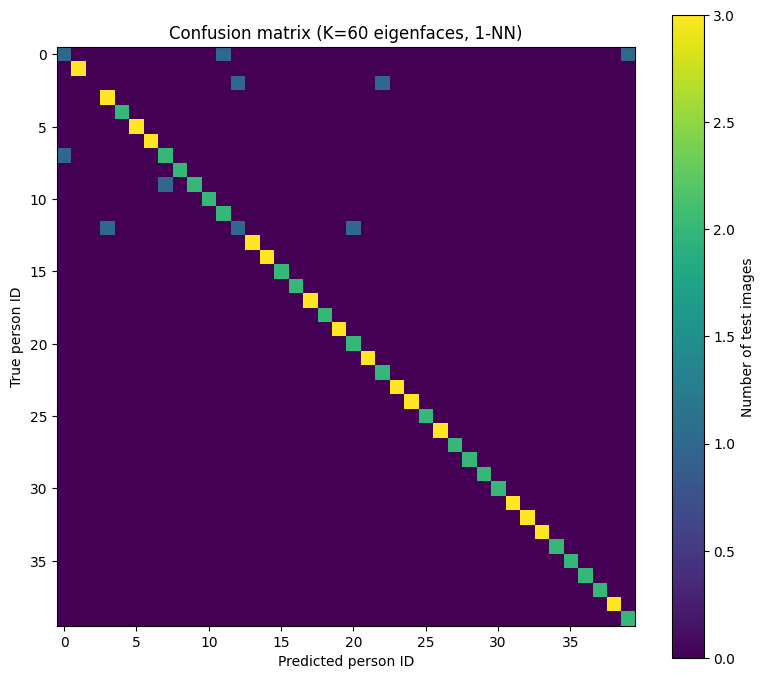

5 hardest people to recognize (id : accuracy):
  person 2: 0%
  person 0: 33%
  person 12: 33%
  person 7: 67%
  person 9: 67%


In [17]:

cm_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm_mat, cmap="viridis")
plt.colorbar(label="Number of test images")
plt.xlabel("Predicted person ID")
plt.ylabel("True person ID")
plt.title(f"Confusion matrix (K={K} eigenfaces, 1-NN)")
plt.tight_layout()
plt.show()

per_person_acc = np.diag(cm_mat) / cm_mat.sum(axis=1)
worst_people = np.argsort(per_person_acc)[:5]
print("5 hardest people to recognize (id : accuracy):")
for p in worst_people:
    print(f"  person {p}: {per_person_acc[p]*100:.0f}%")


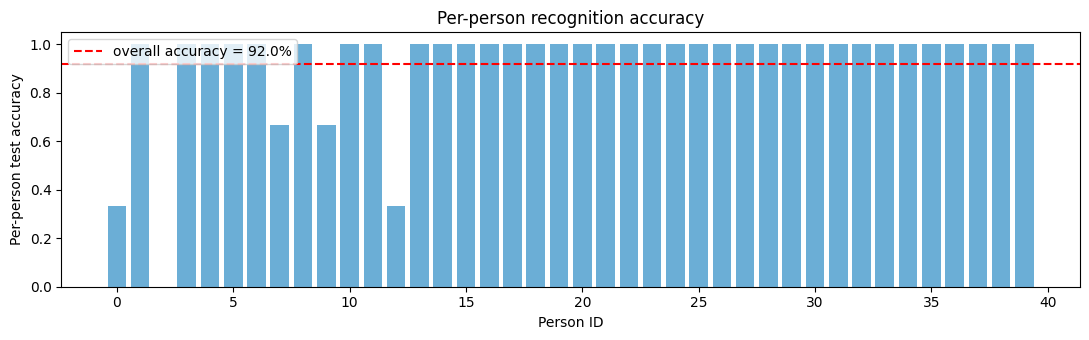

In [18]:

plt.figure(figsize=(11, 3.5))
plt.bar(np.arange(len(per_person_acc)), per_person_acc, color="#6baed6")
plt.axhline(acc, color="red", linestyle="--", label=f"overall accuracy = {acc*100:.1f}%")
plt.xlabel("Person ID")
plt.ylabel("Per-person test accuracy")
plt.title("Per-person recognition accuracy")
plt.legend()
plt.tight_layout()
plt.show()



### 2.4 A 2D map of face space

Even though we used $K=60$ eigenfaces for classification, we can visualize
just the *first two* eigenface coefficients to get an intuitive 2D map of
"face space" — points belonging to the same person should cluster, at least
loosely, since the first two eigenfaces capture the largest sources of
variation.


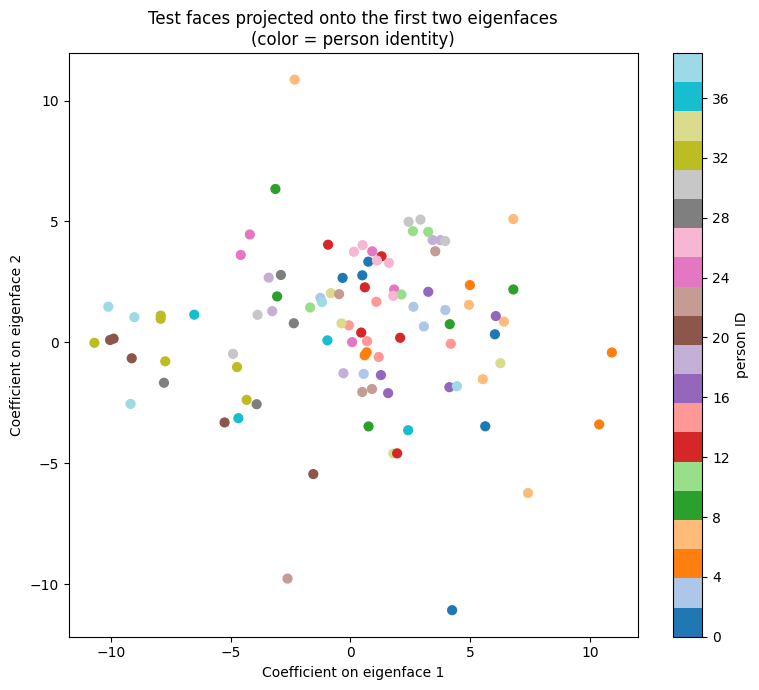

In [19]:

coeffs_2d = project(X_test, mean_face, eigenfaces[:, :2])

plt.figure(figsize=(8, 7))
scatter = plt.scatter(coeffs_2d[:, 0], coeffs_2d[:, 1], c=y_test, cmap="tab20", s=40)
plt.xlabel("Coefficient on eigenface 1")
plt.ylabel("Coefficient on eigenface 2")
plt.title("Test faces projected onto the first two eigenfaces\n(color = person identity)")
plt.colorbar(scatter, label="person ID", ticks=range(0, 40, 4))
plt.tight_layout()
plt.show()



### 2.5 Accuracy vs. number of eigenfaces, on a finer grid of K

Now let's repeat the K-sweep from before, but record the actual accuracy
numbers explicitly (rather than just plotting), and view the curve on both a
linear and a logarithmic K-axis -- the log-x view makes the small-K regime
(where each additional eigenface still helps a lot) much easier to read.


In [20]:

ks = np.array([1, 2, 4, 8, 16, 32, 60])
accs = []
for k in ks:
    ef_k = eigenfaces[:, :k]
    tr_c = project(X_train, mean_face, ef_k)
    te_c = project(X_test, mean_face, ef_k)
    pred = nearest_neighbor_classify(tr_c, y_train, te_c)
    accs.append(accuracy_score(y_test, pred))
print("K values tested:", ks)
print("Accuracies:     ", (100 * np.array(accs)).astype(int))


K values tested: [ 1  2  4  8 16 32 60]
Accuracies:      [15 32 62 82 92 93 92]


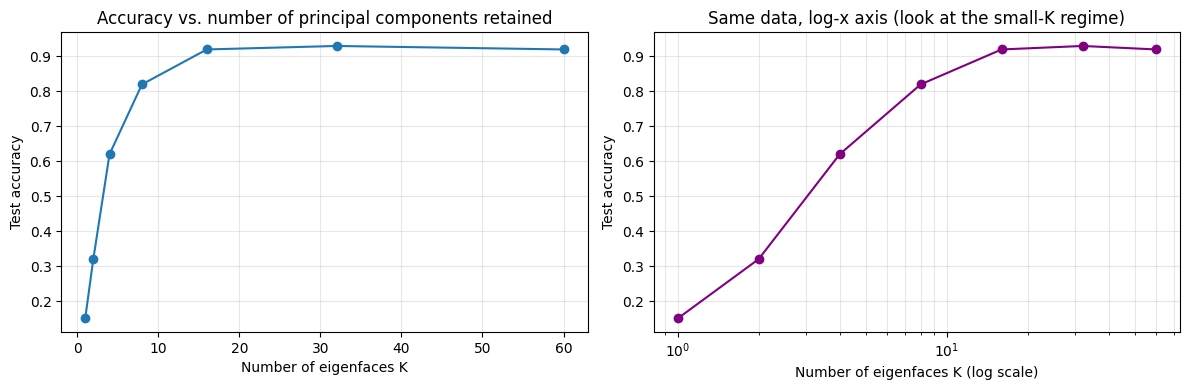

Best accuracy observed: 93.00% at K=32
[PASS] (5/5 pts) Best accuracy across all K values tested is >= 85%  (best=93.0% at K=32)


In [21]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, accs, marker="o")
axes[0].set_xlabel("Number of eigenfaces K")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Accuracy vs. number of principal components retained")
axes[0].grid(alpha=0.3)

axes[1].plot(ks, accs, marker="o", color="purple")
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of eigenfaces K (log scale)")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Same data, log-x axis (look at the small-K regime)")
axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

best_acc = max(accs)
best_k = ks[int(np.argmax(accs))]
print(f"Best accuracy observed: {best_acc*100:.2f}% at K={best_k}")

gb.check("Best accuracy across all K values tested is >= 85%", best_acc >= 0.85, 5,
         detail=f"(best={best_acc*100:.1f}% at K={best_k})");



### Discussion questions — Eigenfaces (be ready to defend your answers)

1. **The $XX^T$ trick, precisely.** Let $X_c \in \mathbb{R}^{n\times d}$ be the
   centered data matrix ($n$ samples, $d$ features, $d \gg n$ here). Let
   $L = \frac{1}{n}X_c X_c^T \in \mathbb{R}^{n\times n}$ and
   $C = \frac{1}{n}X_c^T X_c \in \mathbb{R}^{d\times d}$. Prove that if $u$ is
   a unit eigenvector of $L$ with eigenvalue $\lambda \neq 0$, then
   $v = X_c^T u$ (suitably normalized) is an eigenvector of $C$ with the
   *same* eigenvalue $\lambda$. What happens to the eigenvalues of $C$ that
   are **not** captured this way, and why are we allowed to ignore them when
   $d > n$?

2. **Eckart–Young.** State the Eckart–Young theorem and use it to explain, in
   terms of the *singular values* of $X_c$ (not just informally), in what
   precise sense keeping the top $K$ eigenfaces gives the *provably best*
   rank-$K$ linear reconstruction of the training faces under the Frobenius
   norm. Does this guarantee anything about reconstruction quality on the
   **test** set? Justify your answer instead of just citing intuition — and
   relate it to the train-vs-test MSE plot in section 2.2.

3. **Why centering is mandatory.** Suppose you skip the mean-centering step
   and instead run PCA directly on $X$ (not $X_c$). Show, using the formula
   for $X^TX$ vs. $X_c^TX_c$, exactly what extra rank-1 term appears, and
   explain concretely how this would distort the top eigenfaces if the mean
   face has large norm relative to the per-person variation.

4. **Distance metric.** The 1-NN classifier above uses plain Euclidean
   distance in coefficient space, which implicitly treats every eigenface
   direction as equally important. Derive the **Mahalanobis-style** weighted
   distance that would instead weight each coefficient axis $i$ by
   $1/\sqrt{\lambda_i}$ (the inverse eigenvalue), and argue from the geometry
   of the covariance ellipsoid why this could change — for better or worse —
   the accuracy-vs-K curve you plotted above.

5. **Failure mode.** Construct (in words, no need to code it) a scenario
   involving lighting conditions in which two photographs of two
   *different* people end up closer in eigenface space than two photographs
   of the *same* person, despite a large $K$. What does this tell you about
   the assumption that "directions of large variance = directions useful for
   discrimination," and how does this connect to why Linear Discriminant
   Analysis (Fisherfaces) exists as a follow-up to Eigenfaces?

6. **Confusion matrix forensics.** Look at the confusion matrix and the list
   of "hardest people" you computed in section 2.3. Pick one of the hardest
   people and propose a concrete linear-algebra-based hypothesis (not just
   "bad lighting") for why their eigenface coefficients might be close to
   another person's, referring explicitly to the geometry of nearest-neighbor
   search in a $K$-dimensional coefficient space.


### Answers Here:

1. TODO

2. TODO

3. TODO

4. TODO

5. TODO

6. TODO


## 3. Application 2 — PageRank as an Eigenvector Problem

We model a small set of web pages as a directed graph: an edge $i \to j$
means "page $i$ links to page $j$". PageRank assigns every page a score
equal to the stationary probability that a "random surfer" — who, with
probability $d$ (the damping factor) follows a random outgoing link, and with
probability $1-d$ jumps to a uniformly random page — is on that page after
infinitely many steps.

This stationary distribution is the eigenvector of eigenvalue $1$ of the
**Google matrix**

$$ M = d\,S + \frac{1-d}{N}\mathbf{1}\mathbf{1}^T $$

where $S$ is the column-stochastic version of the link matrix (columns sum to
$1$; dangling nodes — pages with no outgoing links — are replaced by a
uniform column).

We reuse **the exact same `power_iteration` function** from Section 1.


In [22]:

pages = ["A", "B", "C", "D", "E", "F"]
edges = [
    ("A", "B"), ("A", "C"),
    ("B", "C"),
    ("C", "A"),
    ("D", "C"), ("D", "B"),
    ("E", "D"), ("E", "F"),
    ("F", "E"),
]
pages.append("G")  # dangling node: G has zero outgoing links

N = len(pages)
idx = {p: i for i, p in enumerate(pages)}

G = nx.DiGraph()
G.add_nodes_from(pages)
G.add_edges_from(edges)

print(f"Graph has {G.number_of_nodes()} pages and {G.number_of_edges()} links.")
print("In-degrees: ", dict(G.in_degree()))
print("Out-degrees:", dict(G.out_degree()))


Graph has 7 pages and 9 links.
In-degrees:  {'A': 1, 'B': 2, 'C': 3, 'D': 1, 'E': 1, 'F': 1, 'G': 0}
Out-degrees: {'A': 2, 'B': 1, 'C': 1, 'D': 2, 'E': 2, 'F': 1, 'G': 0}


### 3.1 Visualizing the raw graph in several layouts

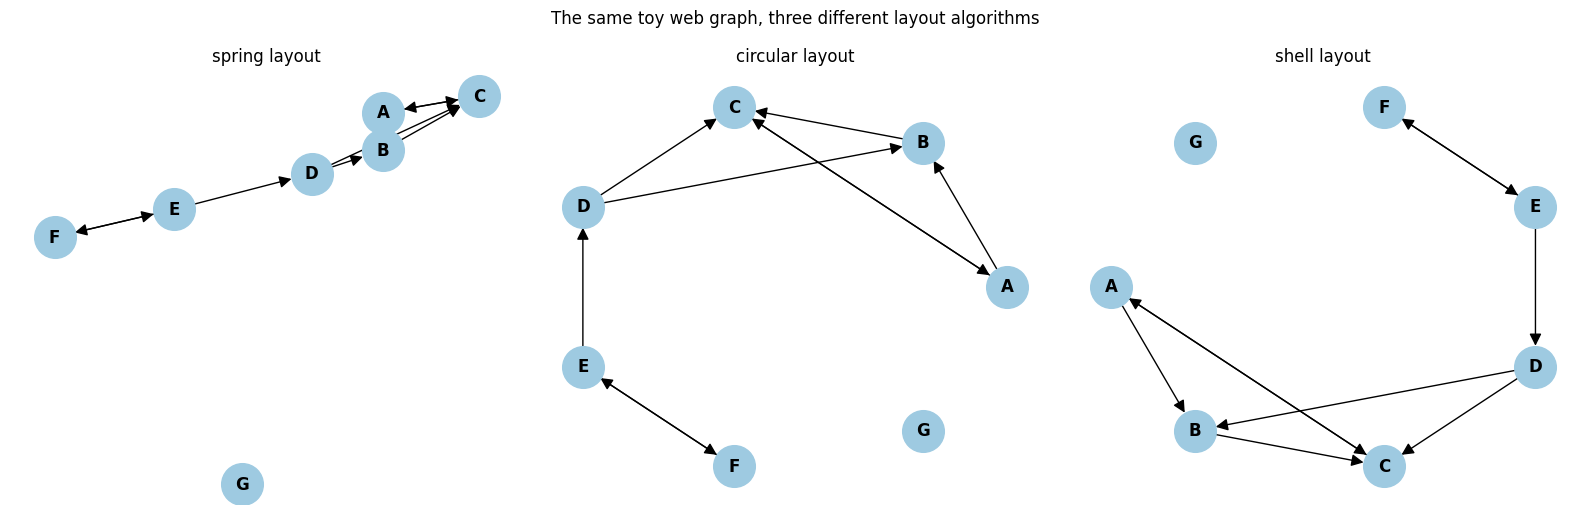

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

layouts = {
    "spring layout": nx.spring_layout(G, seed=3),
    "circular layout": nx.circular_layout(G),
    "shell layout": nx.shell_layout(G),
}

for ax, (name, pos_) in zip(axes, layouts.items()):
    nx.draw(
        G, pos_, ax=ax, with_labels=True, node_color="#9ecae1",
        node_size=900, arrowsize=18, font_weight="bold"
    )
    ax.set_title(name)

plt.suptitle("The same toy web graph, three different layout algorithms")
plt.tight_layout()
plt.show()

pos = layouts["circular layout"]  # we keep using this one for later plots


In [ ]:

def build_link_matrix(pages, edges):
    """
    Build the raw (unnormalized) link matrix H where H[j, i] = 1 if page i
    links to page j (note the transpose convention: columns = source page,
    rows = destination page, so that S @ rank_vector aggregates incoming rank).
    """
    # TODO
    pass


def make_column_stochastic(H):
    """
    Normalize each column to sum to 1. Columns that sum to 0 (dangling
    nodes, i.e. pages with no outgoing links) are replaced with a uniform
    distribution over all pages -- the standard fix so that S remains a
    valid column-stochastic (and hence Markov) matrix.
    """
    # TODO
    pass


def google_matrix(S, d=0.85):
    # TODO
    pass


In [25]:

H, idx = build_link_matrix(pages, edges)
S, dangling = make_column_stochastic(H)
print("Raw link matrix H:")
print(H.astype(int))
print("\nDangling nodes:", [pages[i] for i in dangling])

d = 0.85
M = google_matrix(S, d=d)

col_sums_S_ok = np.allclose(S.sum(axis=0), 1.0)
col_sums_M_ok = np.allclose(M.sum(axis=0), 1.0)
print("Column sums of S (should all be 1):", np.round(S.sum(axis=0), 6))
print("Column sums of M (should all be 1):", np.round(M.sum(axis=0), 6))

gb.check("S is column-stochastic (columns sum to 1)", col_sums_S_ok, 3)
gb.check("M is column-stochastic (columns sum to 1)", col_sums_M_ok, 3);


Raw link matrix H:
[[0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0]
 [1 1 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0]]

Dangling nodes: ['G']
Column sums of S (should all be 1): [1. 1. 1. 1. 1. 1. 1.]
Column sums of M (should all be 1): [1. 1. 1. 1. 1. 1. 1.]
[PASS] (3/3 pts) S is column-stochastic (columns sum to 1)  
[PASS] (3/3 pts) M is column-stochastic (columns sum to 1)  


### 3.2 Heatmaps of the link, stochastic, and Google matrices

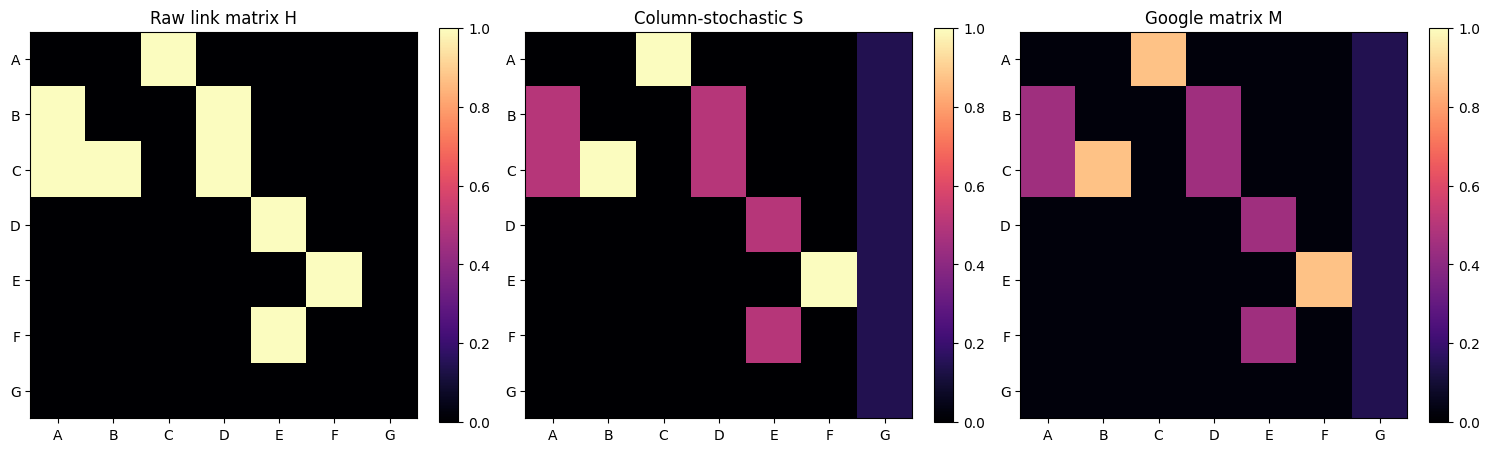

In [26]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mat, title in zip(axes, [H, S, M], ["Raw link matrix H", "Column-stochastic S", "Google matrix M"]):
    im = ax.imshow(mat, cmap='magma')
    ax.set_xticks(range(N)); ax.set_xticklabels(pages)
    ax.set_yticks(range(N)); ax.set_yticklabels(pages)
    ax.set_title(title)
    im.set_clim(0, 1)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


In [27]:

lam, rank_vector, n_iter, history = power_iteration(M, num_iters=500, tol=1e-12, seed=7)

# Power iteration returns a vector with possibly mixed sign / not a probability
# distribution yet: PageRank requires a non-negative vector summing to 1.
rank_vector = np.abs(rank_vector)
rank_vector = rank_vector / rank_vector.sum()

print(f"Dominant eigenvalue: {lam:.8f}  (theory says this must equal 1)")
print(f"Converged in {n_iter} iterations")
print()
for p, r in sorted(zip(pages, rank_vector), key=lambda t: -t[1]):
    print(f"  {p}: {r:.4f}")

eigval_is_one = abs(lam - 1.0) < 1e-6
gb.check("Dominant eigenvalue of the Google matrix equals 1", eigval_is_one, 4, detail=f"(got {lam:.6f})");


Dominant eigenvalue: 1.00000000  (theory says this must equal 1)
Converged in 56 iterations

  C: 0.3228
  A: 0.2988
  B: 0.1745
  E: 0.0706
  D: 0.0544
  F: 0.0544
  G: 0.0244
[PASS] (4/4 pts) Dominant eigenvalue of the Google matrix equals 1  (got 1.000000)


In [28]:

# Validate against numpy's exact eigendecomposition of M.
vals_np, vecs_np = np.linalg.eig(M)
i_dom = np.argmax(vals_np.real)
v_np = np.abs(vecs_np[:, i_dom].real)
v_np = v_np / v_np.sum()

print("power_iteration ranks: ", np.round(rank_vector, 5))
print("numpy.linalg.eig ranks:", np.round(v_np, 5))

pagerank_matches_numpy = np.allclose(rank_vector, v_np, atol=1e-3)
print("\nMatch confirmed:", pagerank_matches_numpy)

gb.check("PageRank vector matches numpy.linalg.eig (atol=1e-3)", pagerank_matches_numpy, 8)
gb.check("Page C is ranked #1 (it has the most structurally-backed incoming links)",
         pages[np.argmax(rank_vector)] == "C", 3);


power_iteration ranks:  [0.2988  0.17451 0.32284 0.05441 0.07064 0.05441 0.02439]
numpy.linalg.eig ranks: [0.2988  0.17451 0.32284 0.05441 0.07064 0.05441 0.02439]

Match confirmed: True
[PASS] (8/8 pts) PageRank vector matches numpy.linalg.eig (atol=1e-3)  
[PASS] (3/3 pts) Page C is ranked #1 (it has the most structurally-backed incoming links)  


### 3.3 Visualizing convergence: how the rank vector evolves, iteration by iteration

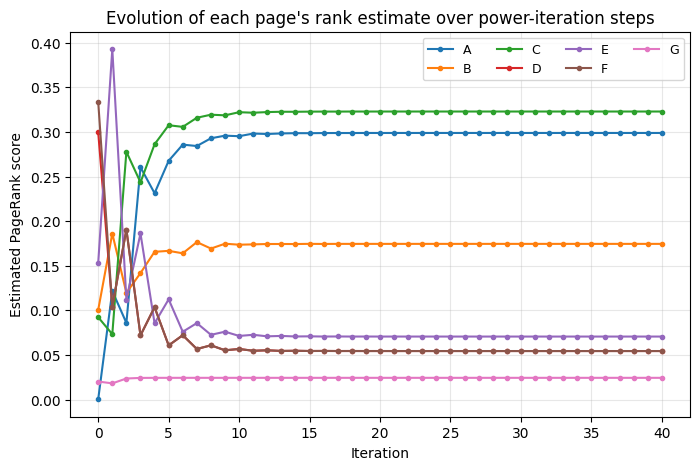

In [ ]:

def power_iteration_trace(A, num_iters, v0=None, seed=None):
    """Like power_iteration, but returns the FULL sequence of vectors (for plotting)."""
    # TODO
    pass


trace = power_iteration_trace(M, num_iters=40, seed=7)
trace = np.abs(trace)
trace = trace / trace.sum(axis=1, keepdims=True)  # normalize each row to a probability vector

plt.figure(figsize=(8, 5))
for i, p in enumerate(pages):
    plt.plot(trace[:, i], marker=".", label=p)
plt.xlabel("Iteration")
plt.ylabel("Estimated PageRank score")
plt.title("Evolution of each page's rank estimate over power-iteration steps")
plt.legend(ncol=4, fontsize=9)
plt.grid(alpha=0.3)
plt.show()


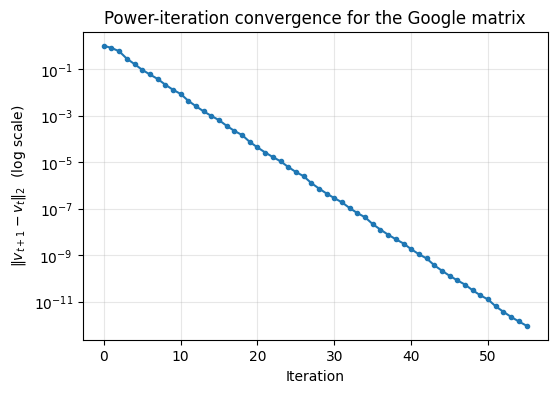

In [30]:

plt.figure(figsize=(6, 4))
plt.semilogy(history, marker=".")
plt.xlabel("Iteration")
plt.ylabel(r"$\|v_{t+1} - v_t\|_2$  (log scale)")
plt.title("Power-iteration convergence for the Google matrix")
plt.grid(alpha=0.3)
plt.show()


### 3.4 The web graph, redrawn so node size/color encode PageRank score

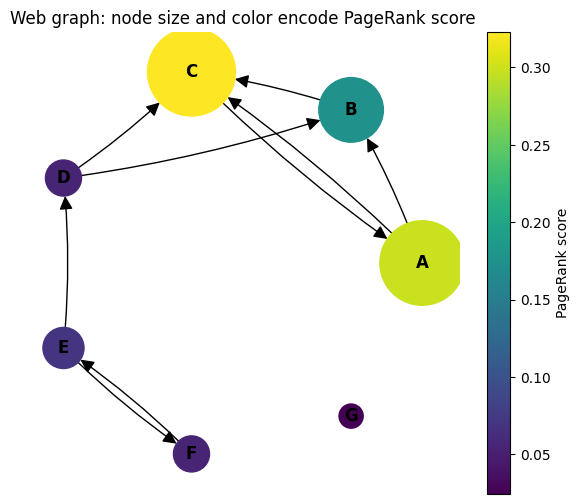

In [31]:

fig, ax = plt.subplots(figsize=(7, 6))
node_sizes = 4000 * rank_vector / rank_vector.max()
colors = [rank_vector[idx[p]] for p in pages]
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=colors,
                                cmap="viridis", ax=ax)
nx.draw_networkx_edges(G, pos, node_size=node_sizes, arrowsize=20, ax=ax, connectionstyle="arc3,rad=0.05")
nx.draw_networkx_labels(G, pos, font_weight="bold", ax=ax)
plt.colorbar(nodes, ax=ax, label="PageRank score")
plt.title("Web graph: node size and color encode PageRank score")
plt.axis("off")
plt.show()


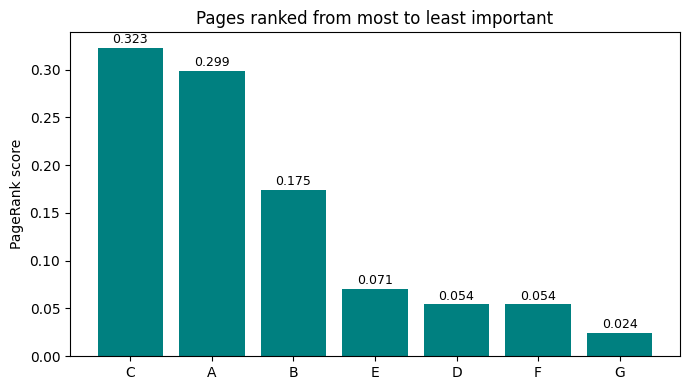

In [32]:

order_idx = np.argsort(-rank_vector)
plt.figure(figsize=(7, 4))
plt.bar([pages[i] for i in order_idx], rank_vector[order_idx], color="teal")
plt.ylabel("PageRank score")
plt.title("Pages ranked from most to least important")
for i, oi in enumerate(order_idx):
    plt.text(i, rank_vector[oi] + 0.005, f"{rank_vector[oi]:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()



### 3.5 What happens if we add a new backlink?

A classic "SEO" experiment: suppose page `G` (currently dangling, i.e.
contributing no outgoing links) adds a single link to page `F`. Intuitively,
this should change `F`'s rank — but by how much, and does it disturb anyone
else? Let's actually compute it instead of guessing.


page  rank (before)   rank (after G->F) change    
C     0.3228          0.3081            -0.0148
A     0.2988          0.2833            -0.0155
B     0.1745          0.1665            -0.0080
E     0.0706          0.0863            +0.0157
F     0.0544          0.0763            +0.0219
D     0.0544          0.0581            +0.0037
G     0.0244          0.0214            -0.0030


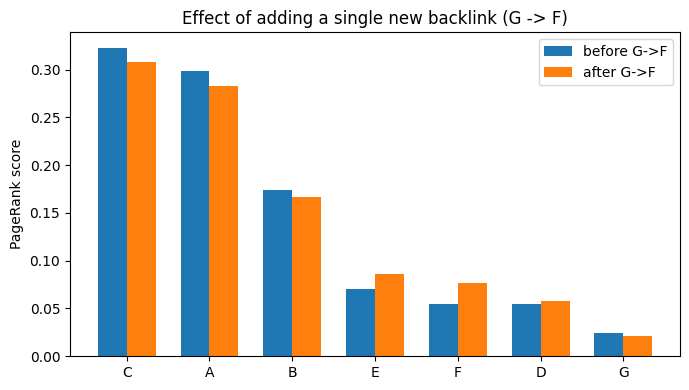

In [33]:

edges_v2 = edges + [("G", "F")]
H2, _ = build_link_matrix(pages, edges_v2)
S2, dangling2 = make_column_stochastic(H2)
M2 = google_matrix(S2, d=d)

_, rank_vector_v2, _, _ = power_iteration(M2, num_iters=500, tol=1e-12, seed=7)
rank_vector_v2 = np.abs(rank_vector_v2)
rank_vector_v2 = rank_vector_v2 / rank_vector_v2.sum()

comparison = sorted(zip(pages, rank_vector, rank_vector_v2), key=lambda t: -t[2])
print(f"{'page':6s}{'rank (before)':16s}{'rank (after G->F)':18s}{'change':10s}")
for p, before, after in comparison:
    print(f"{p:6s}{before:<16.4f}{after:<18.4f}{after-before:+.4f}")

plt.figure(figsize=(7, 4))
x = np.arange(len(pages))
width = 0.35
order_idx2 = np.argsort(-rank_vector_v2)
plt.bar(x - width/2, rank_vector[order_idx2], width, label="before G->F")
plt.bar(x + width/2, rank_vector_v2[order_idx2], width, label="after G->F")
plt.xticks(x, [pages[i] for i in order_idx2])
plt.ylabel("PageRank score")
plt.title("Effect of adding a single new backlink (G -> F)")
plt.legend()
plt.tight_layout()
plt.show()


### 3.6 Sensitivity to the damping factor $d$

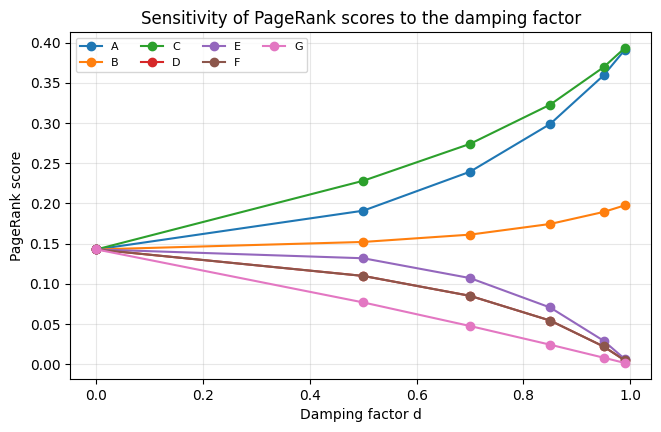

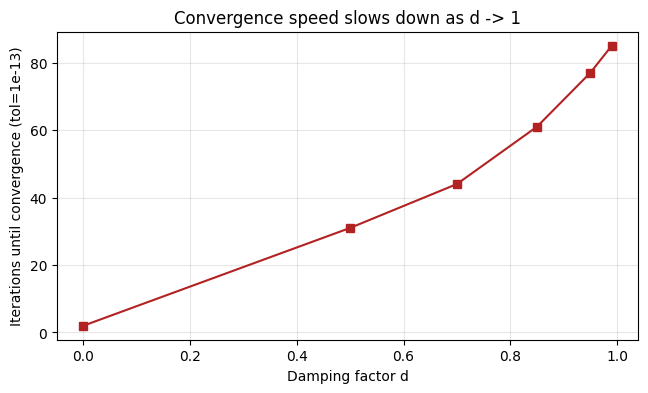

In [ ]:

def pagerank_for_d(pages, edges, d):
    # TODO
    pass

d_values = [0.0, 0.5, 0.7, 0.85, 0.95, 0.99]
scores_by_d = {}
iters_by_d = {}
for d_ in d_values:
    scores_by_d[d_], iters_by_d[d_] = pagerank_for_d(pages, edges, d_)

plt.figure(figsize=(7.5, 4.5))
for p_i, p in enumerate(pages):
    plt.plot(d_values, [scores_by_d[d_][p_i] for d_ in d_values], marker="o", label=p)
plt.xlabel("Damping factor d")
plt.ylabel("PageRank score")
plt.title("Sensitivity of PageRank scores to the damping factor")
plt.legend(ncol=4, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7.5, 4))
plt.plot(d_values, [iters_by_d[d_] for d_ in d_values], marker="s", color="firebrick")
plt.xlabel("Damping factor d")
plt.ylabel("Iterations until convergence (tol=1e-13)")
plt.title("Convergence speed slows down as d -> 1")
plt.grid(alpha=0.3)
plt.show()


In [35]:

# A concrete, checkable consequence of the theory in discussion question 3
# below: convergence should get monotonically SLOWER (more iterations needed)
# as d increases towards 1.
iters_list = [iters_by_d[d_] for d_ in d_values]
mostly_increasing = sum(iters_list[i] <= iters_list[i+1] for i in range(len(iters_list)-1)) >= len(iters_list) - 2

gb.check("Convergence iterations roughly increase with damping factor d", mostly_increasing, 4);


[PASS] (4/4 pts) Convergence iterations roughly increase with damping factor d  



### 3.7 Spectral gap: why does convergence speed depend on $d$?

Power iteration's convergence rate is controlled by the ratio
$|\lambda_2/\lambda_1|$ of the second-largest to the largest eigenvalue
magnitude. Let's actually compute the full eigenvalue spectrum of $M$ (using
`numpy.linalg.eig`, since we only need this for *inspection*, not as part of
our power-iteration pipeline) and look at the gap.


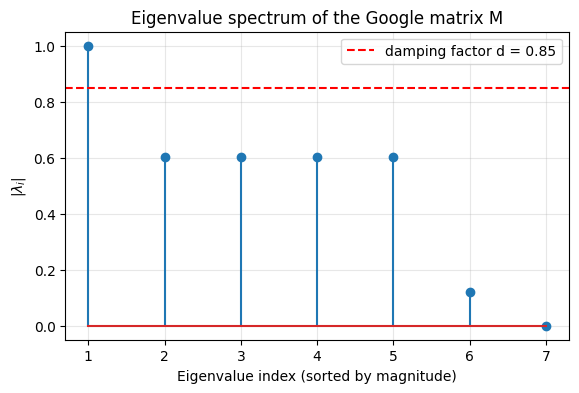

Magnitudes of all eigenvalues of M, sorted: [1.     0.601  0.601  0.601  0.601  0.1214 0.    ]
lambda_1 = 1.000000   |lambda_2| = 0.601041   ratio |lambda_2/lambda_1| = 0.601041
(theory guarantees |lambda_2| <= d = 0.85)
[PASS] (5/5 pts) |lambda_2| <= damping factor d, as guaranteed by theory  (|lambda_2|=0.6010, d=0.85)


In [36]:

eigvals_M = np.linalg.eigvals(M)
mags = np.sort(np.abs(eigvals_M))[::-1]

plt.figure(figsize=(6.5, 4))
plt.stem(range(1, len(mags) + 1), mags)
plt.axhline(d, color="red", linestyle="--", label=f"damping factor d = {d}")
plt.xlabel("Eigenvalue index (sorted by magnitude)")
plt.ylabel(r"$|\lambda_i|$")
plt.title("Eigenvalue spectrum of the Google matrix M")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Magnitudes of all eigenvalues of M, sorted:", np.round(mags, 4))
print(f"lambda_1 = {mags[0]:.6f}   |lambda_2| = {mags[1]:.6f}   ratio |lambda_2/lambda_1| = {mags[1]/mags[0]:.6f}")
print(f"(theory guarantees |lambda_2| <= d = {d})")

gap_bound_holds = mags[1] <= d + 1e-9
gb.check("|lambda_2| <= damping factor d, as guaranteed by theory", gap_bound_holds, 5,
         detail=f"(|lambda_2|={mags[1]:.4f}, d={d})");



### Discussion questions — PageRank (be ready to defend your answers)

1. **Perron–Frobenius, applied.** State the Perron–Frobenius theorem for
   positive (or irreducible, aperiodic non-negative) matrices. Prove that for
   any $d \in (0,1)$, the Google matrix $M = dS + \frac{1-d}{N}\mathbf{1}\mathbf{1}^T$
   is **strictly positive** in every entry. Use this fact (not hand-waving) to
   argue why $M$ is guaranteed to have a *unique* dominant eigenvalue equal to
   exactly $1$, with a strictly positive eigenvector — and explain precisely
   *where* this argument breaks down at $d = 1$.

2. **Why deflation does not apply here.** In Section 1, we used deflation
   ($A \leftarrow A - \lambda v v^T$) to extract several eigenpairs because
   the covariance matrix is symmetric. $M$ is generally **not** symmetric.
   Explain, in terms of left vs. right eigenvectors, why the deflation trick
   used for eigenfaces is invalid for a general (non-symmetric) matrix like
   $M$, and what would have to change about the algorithm to adapt it.

3. **Convergence rate.** Power iteration's convergence rate is governed by
   the ratio $|\lambda_2 / \lambda_1|$, where $\lambda_1 = 1 > |\lambda_2| \geq \dots$
   are $M$'s eigenvalues sorted by magnitude. It is a known fact that for the
   Google matrix, $|\lambda_2| \leq d$ (you just verified this numerically in
   section 3.7). Using this bound, derive (do the algebra, don't just state
   it) an expression for the minimum number of iterations needed to
   guarantee $\|v_t - v^*\| < \varepsilon$ for a given tolerance
   $\varepsilon$, as a function of $d$ and $\varepsilon$. Then explain,
   quantitatively using this formula, why your convergence-vs-$d$ plot in
   section 3.6 gets dramatically slower as $d \to 1$.

4. **Dangling nodes, two different fixes.** We fixed dangling node `G` by
   replacing its all-zero column with a uniform column $\frac{1}{N}\mathbf 1$.
   An alternative fix used in some implementations is to instead make a
   dangling node link **only to itself** (a self-loop). Show, with a concrete
   small example (you may reuse or modify the 7-page graph), how these two
   fixes can produce *different* PageRank rankings, and argue which one is
   more faithful to the "random surfer" interpretation of PageRank and why.

5. **Disconnected web.** Suppose the 7-page graph above is split into two
   components with **no edges at all between them** (delete edges
   `E->D`, `D->C`, and `D->B`, fully separating $\{A,B,C\}$ from
   $\{D,E,F,G\}$). At $d=1$ exactly, explain why $S$ (not $M$) would then have
   eigenvalue $1$ with **multiplicity two**, and why this would make plain
   power iteration on $S$ (without the damping term) fail to converge to a
   well-defined single ranking. Connect this back to why the
   $\frac{1-d}{N}\mathbf{1}\mathbf{1}^T$ term is not just a "tie-breaking hack"
   but a structural necessity.

6. **The backlink experiment.** In section 3.5 you computed the exact effect
   of adding the edge `G -> F`. Looking at your numeric output: did *every*
   page's score change, or only some? Explain, in terms of which entries of
   $S$ and $M$ actually changed, why the effect of a single new edge does
   or does not stay perfectly local to the two endpoints of that edge.


### Answers Here:

1. TODO

2. TODO

3. TODO

4. TODO

5. TODO

6. TODO


## 4. Closing Synthesis Question

Both eigenfaces and PageRank reduce to: *"build a square matrix that encodes
some notion of similarity/influence, then find its dominant eigenstructure."*

Write a short (10–15 sentence) comparison, addressing **all** of the
following explicitly:

- In eigenfaces we want the top-$K$ eigenvectors of a **symmetric, positive
  semi-definite** matrix; in PageRank we want exactly **one** eigenvector of a
  matrix that is generally **not symmetric**. Explain how each property
  (symmetry vs. non-symmetry, needing $K$ vectors vs. needing $1$) directly
  determined an algorithmic choice we made in this notebook (deflation vs.
  no deflation; arbitrary normalization vs. damping factor).
- If someone asked you to compute the eigenfaces of a $4096\times 4096$
  covariance matrix using `numpy.linalg.eig` directly (no $XX^T$ trick, no
  power iteration), versus computing PageRank of a million-page web graph
  using `numpy.linalg.eig` on the full $10^6 \times 10^6$ Google matrix
  directly: which of these two would fail first, and why, in terms of time
  complexity, memory, and the **sparsity** structure of the underlying
  matrix? Be specific about the asymptotic complexity of dense
  eigendecomposition versus the cost of one power-iteration step on a sparse
  matrix.


### Answer Here:

1. TODO

2. TODO


## 5. Final Report Card

Run the cell below to print your full score across every check defined in
this notebook. Nothing here is hidden: scroll back up and you will find every
single one of these checks sitting in plain code, in the cell where it
logically belongs, right after the computation it is testing.


In [37]:

earned, total = gb.report()


CHECK                                             RESULT  POINTS    
------------------------------------------------------------------------------
top_k_eigenvalues_symmetric matches numpy (10x10, top-5)PASS    5/5       
top_k_eigenvectors_symmetric matches numpy (10x10, top-5)PASS    5/5       
Eigenvalues of the covariance matrix are non-negative (PSD check)PASS    3/3       
Training reconstruction MSE is non-increasing in K (Eckart-Young)PASS    4/4       
Eigenfaces + 1-NN test accuracy >= 80% (K=60)     PASS    10/10     
Eigenfaces + 1-NN test accuracy >= 90% (K=60)     PASS    5/5       
Best accuracy across all K values tested is >= 85%PASS    5/5       
S is column-stochastic (columns sum to 1)         PASS    3/3       
M is column-stochastic (columns sum to 1)         PASS    3/3       
Dominant eigenvalue of the Google matrix equals 1 PASS    4/4       
PageRank vector matches numpy.linalg.eig (atol=1e-3)PASS    8/8       
Page C is ranked #1 (it has the most structurall